# 01 · Backpropagation

To train a network with gradient descent we need $\nabla_{\boldsymbol{\theta}}J$ for **every** weight and bias. Backpropagation computes all of them in one backward sweep, at roughly the cost of a forward pass. It is nothing more than the chain rule, organised so that no computation is repeated.

**Contents**

1. Why we need an efficient method
2. The chain rule on a computational graph (worked example)
3. Backpropagation for an MLP: derivation
4. The algorithm
5. Implementation from scratch + gradient checking
6. Initialisation: why not zeros, and how large (Xavier / He)
7. Vanishing and exploding gradients
8. Automatic differentiation in PyTorch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Why we need an efficient method

A modern network has millions of parameters. The naive way to get a gradient, finite differences $\frac{\partial J}{\partial\theta_k}\approx\frac{J(\boldsymbol{\theta}+\varepsilon\mathbf{e}_k) - J(\boldsymbol{\theta}-\varepsilon\mathbf{e}_k)}{2\varepsilon}$, needs **two forward passes per parameter**. Backpropagation gets all of them with **one forward and one backward pass** (the backward pass costs about twice the forward). It is a special case of **reverse-mode automatic differentiation**: efficient whenever there are many inputs (parameters) and one output (the scalar loss).

## 2. The chain rule on a computational graph

Any computation can be drawn as a graph of elementary operations. **Forward**: compute every node's value from its inputs. **Backward**: starting from $\frac{\partial J}{\partial J} = 1$, send each node's gradient to its inputs, multiplying by the **local derivative**. Where a value feeds several nodes, the incoming gradients **add up** (multivariate chain rule).

**Worked example.** One neuron, one example: $z = wx + b$, $a = \sigma(z)$, $J = -[y\log a + (1-y)\log(1-a)]$, with $x = 2$, $w = -0.5$, $b = 0.3$, $y = 1$.

| Step | Forward | Backward (chain rule) |
|---|---|---|
| $z = wx + b$ | $-0.5\cdot2 + 0.3 = -0.7$ | $\frac{\partial J}{\partial w} = \frac{\partial J}{\partial z}\,x$, $\;\frac{\partial J}{\partial b} = \frac{\partial J}{\partial z}\cdot1$ |
| $a = \sigma(z)$ | $\sigma(-0.7) = 0.332$ | $\frac{\partial J}{\partial z} = \frac{\partial J}{\partial a}\,a(1-a)$ |
| $J = -\log a$ | $1.103$ | $\frac{\partial J}{\partial a} = -\frac{1}{a} = -3.014$ |

Backward numbers: $\frac{\partial J}{\partial z} = -3.014\cdot0.332\cdot0.668 = -0.668 = a - y$ (the simplification of ML notes 02), $\frac{\partial J}{\partial w} = -0.668\cdot2 = -1.336$, $\frac{\partial J}{\partial b} = -0.668$.

In [2]:
x, w, b, y = 2.0, -0.5, 0.3, 1.0
sig = lambda z: 1 / (1 + np.exp(-z))
z = w * x + b; a = sig(z); J = -np.log(a)
dJ_da = -1 / a; dJ_dz = dJ_da * a * (1 - a); dJ_dw = dJ_dz * x; dJ_db = dJ_dz
print(f"forward : z={z:.3f}  a={a:.3f}  J={J:.3f}")
print(f"backward: dJ/da={dJ_da:.3f}  dJ/dz={dJ_dz:.3f} (a-y={a-y:.3f})  dJ/dw={dJ_dw:.3f}  dJ/db={dJ_db:.3f}")
eps = 1e-6; Jf = lambda w_: -np.log(sig(w_ * x + b))
print(f"finite-difference dJ/dw = {(Jf(w + eps) - Jf(w - eps)) / (2 * eps):.3f}")

forward : z=-0.700  a=0.332  J=1.103
backward: dJ/da=-3.014  dJ/dz=-0.668 (a-y=-0.668)  dJ/dw=-1.336  dJ/db=-0.668
finite-difference dJ/dw = -1.336


## 3. Backpropagation for an MLP: derivation

Forward pass (notebook 00): $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}$, $\;\mathbf{A}^{[l]} = g^{[l]}(\mathbf{Z}^{[l]})$, and $J$ is the **mean** loss over the $m$ rows.

Define the **error signal** of layer $l$ as the gradient of the loss w.r.t. its pre-activations:
$$
\boldsymbol{\delta}^{[l]} = \frac{\partial J}{\partial\mathbf{Z}^{[l]}} \in \mathbb{R}^{m\times n_l}.
$$

**(a) Output layer.** For the three "matching" pairs (identity + ½·MSE, sigmoid + BCE, softmax + cross-entropy) the derivative w.r.t. the logits is the same simple expression (ML notes 01, 02, 04):
$$
\boldsymbol{\delta}^{[L]} = \frac{1}{m}\big(\mathbf{A}^{[L]} - \mathbf{Y}\big).
$$
(The $\frac1m$ comes from averaging.)

**(b) From $\boldsymbol{\delta}^{[l]}$ to the parameters of layer $l$.** Write the linear step in indices: $Z_{ik} = \sum_j A_{ij}W_{jk} + b_k$ (with $\mathbf{A} = \mathbf{A}^{[l-1]}$, $\mathbf{W} = \mathbf{W}^{[l]}$). $W_{jk}$ affects $Z_{ik}$ for every example $i$, with $\partial Z_{ik}/\partial W_{jk} = A_{ij}$, so
$$
\frac{\partial J}{\partial W_{jk}} = \sum_i \delta_{ik}A_{ij} = \big(\mathbf{A}^\top\boldsymbol{\delta}\big)_{jk}
\quad\Rightarrow\quad
\boxed{\frac{\partial J}{\partial\mathbf{W}^{[l]}} = \mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]}},
\qquad
\boxed{\frac{\partial J}{\partial\mathbf{b}^{[l]}} = \sum_{i=1}^m\boldsymbol{\delta}^{[l]}_{i,:}}
$$
(the bias gradient sums $\boldsymbol{\delta}$ over the batch, because $b_k$ is added to every row).

**(c) From $\boldsymbol{\delta}^{[l]}$ back to the previous layer.** $A_{ij}$ affects $Z_{ik}$ for every unit $k$, with $\partial Z_{ik}/\partial A_{ij} = W_{jk}$:
$$
\frac{\partial J}{\partial A_{ij}} = \sum_k\delta_{ik}W_{jk} = \big(\boldsymbol{\delta}\mathbf{W}^\top\big)_{ij}.
$$
Then $\mathbf{A}^{[l-1]} = g(\mathbf{Z}^{[l-1]})$ acts element by element, so each entry just picks up the local derivative:
$$
\boxed{\boldsymbol{\delta}^{[l-1]} = \big(\boldsymbol{\delta}^{[l]}\mathbf{W}^{[l]\top}\big)\odot g^{[l-1]\prime}\big(\mathbf{Z}^{[l-1]}\big)}
$$
where $\odot$ is element-wise multiplication. $\blacksquare$

**Sanity check with shapes.** $\mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]}$ is $(n_{l-1}\times m)(m\times n_l) = n_{l-1}\times n_l$, the shape of $\mathbf{W}^{[l]}$. $\boldsymbol{\delta}^{[l]}\mathbf{W}^{[l]\top}$ is $(m\times n_l)(n_l\times n_{l-1}) = m\times n_{l-1}$, the shape of $\mathbf{Z}^{[l-1]}$. If you forget the formulas, the shapes almost force them.

**Link to linear/logistic regression.** With one layer ($L=1$, $\mathbf{A}^{[0]} = \mathbf{X}$), (a) + (b) give $\nabla_{\mathbf{W}}J = \frac1m\mathbf{X}^\top(\hat{\mathbf{Y}} - \mathbf{Y})$: exactly the gradients of the ML notes.

## 4. The algorithm

```
forward:   A[0] = X
           for l = 1..L:  Z[l] = A[l-1] W[l] + b[l];   A[l] = g[l](Z[l])      (store Z[l], A[l])
           J = loss(A[L], Y)
backward:  δ[L] = (A[L] - Y) / m
           for l = L..1:
               dW[l] = A[l-1]^T δ[l]
               db[l] = sum of δ[l] over rows
               if l > 1:  δ[l-1] = (δ[l] W[l]^T) ⊙ g'[l-1](Z[l-1])
update:    W[l] -= α dW[l];   b[l] -= α db[l]
```

The forward pass must **store** the intermediate $\mathbf{Z}^{[l]}, \mathbf{A}^{[l]}$, because the backward pass reuses them. That is why training uses much more memory than inference (and why `torch.no_grad()` saves memory at evaluation time).

In [3]:
class MLP:
    """Fully connected net, ReLU hidden layers, sigmoid output, BCE loss. Row-major: Z = A W + b."""
    def __init__(self, sizes, rng, init="he"):
        scale = {"he": lambda n: np.sqrt(2 / n), "small": lambda n: 0.01, "zeros": lambda n: 0.0}[init]
        self.W = [rng.normal(0, 1, (a, b)) * scale(a) for a, b in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros((1, b)) for b in sizes[1:]]

    def forward(self, X):
        self.A, self.Z = [X], []
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = self.A[-1] @ W + b
            A = 1 / (1 + np.exp(-Z)) if l == len(self.W) - 1 else np.maximum(0, Z)
            self.Z.append(Z); self.A.append(A)
        return self.A[-1]

    def loss(self, X, Y, eps=1e-12):
        P = self.forward(X)
        return -np.mean(Y * np.log(P + eps) + (1 - Y) * np.log(1 - P + eps))

    def backward(self, Y):
        m, L = len(Y), len(self.W)
        dW, db = [None] * L, [None] * L
        delta = (self.A[-1] - Y) / m                                  # (a) output layer
        for l in reversed(range(L)):
            dW[l] = self.A[l].T @ delta                               # (b) parameters
            db[l] = delta.sum(axis=0, keepdims=True)
            if l > 0:
                delta = (delta @ self.W[l].T) * (self.Z[l - 1] > 0)   # (c) previous layer, ReLU' = 1[z>0]
        return dW, db

## 5. Gradient checking, then training

Always verify a hand-written backward pass against finite differences on a small network. The **relative error** $\frac{\lVert g_{\text{bp}} - g_{\text{num}}\rVert}{\lVert g_{\text{bp}}\rVert + \lVert g_{\text{num}}\rVert}$ should be around $10^{-7}$ or smaller (in float64).

In [4]:
Xs = rng.normal(size=(20, 3)); Ys = (rng.random((20, 1)) > 0.5).astype(float)
net = MLP([3, 5, 4, 1], rng)
net.loss(Xs, Ys); dW, db = net.backward(Ys)
num, ana, eps = [], [], 1e-6
for l in range(len(net.W)):
    for idx in np.ndindex(net.W[l].shape):
        old = net.W[l][idx]
        net.W[l][idx] = old + eps; Jp = net.loss(Xs, Ys)
        net.W[l][idx] = old - eps; Jm = net.loss(Xs, Ys)
        net.W[l][idx] = old
        num.append((Jp - Jm) / (2 * eps)); ana.append(dW[l][idx])
num, ana = np.array(num), np.array(ana)
print(f"{len(num)} weights checked, relative error = {np.linalg.norm(num - ana) / (np.linalg.norm(num) + np.linalg.norm(ana)):.2e}")

39 weights checked, relative error = 7.46e-10


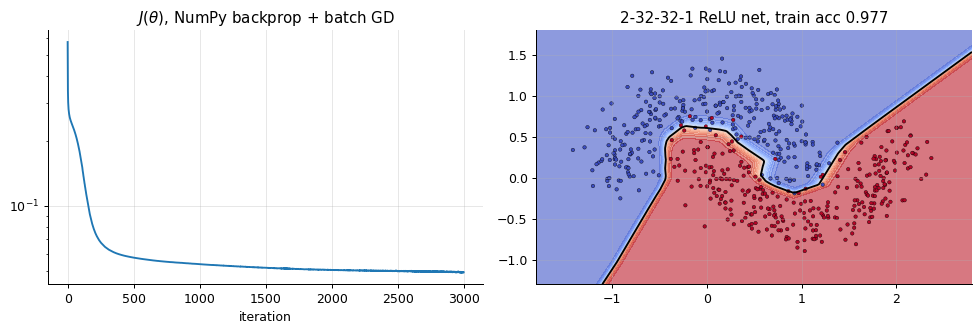

In [5]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=600, noise=0.2, random_state=0); Ym = ym[:, None].astype(float)
net = MLP([2, 32, 32, 1], rng)
alpha, costs = 0.5, []
for epoch in range(3000):                           # full-batch gradient descent
    costs.append(net.loss(Xm, Ym))
    dW, db = net.backward(Ym)
    for l in range(len(net.W)):
        net.W[l] -= alpha * dW[l]; net.b[l] -= alpha * db[l]

g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 300), np.linspace(-1.3, 1.8, 300))
P = net.forward(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(costs); axes[0].set_yscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_title(r"$J(\theta)$, NumPy backprop + batch GD")
axes[1].contourf(g1, g2, P, levels=20, cmap="coolwarm", alpha=0.6); axes[1].contour(g1, g2, P, levels=[0.5], colors="k")
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=8, edgecolor="k", lw=0.3)
axes[1].set_title(f"2-32-32-1 ReLU net, train acc {np.mean((net.forward(Xm) > 0.5) == Ym):.3f}")
plt.tight_layout(); plt.show()

## 6. Initialisation

**Why not all zeros (or all equal)?** If every weight in a layer starts equal, all units in that layer compute the same $z$, get the same $\boldsymbol{\delta}$ column (formula (c) is symmetric in the units), hence the same update, and so they **stay identical forever**. The layer behaves like a single unit. *Random* initialisation breaks this symmetry. (With exactly zero weights and ReLU it is even worse: $\boldsymbol{\delta}\mathbf{W}^\top = 0$ and nothing below the output layer ever learns.)

**How large?** Consider one layer with $n_{\text{in}}$ inputs, independent zero-mean weights of variance $\mathrm{Var}(w)$, independent of the inputs. Then
$$
\mathrm{Var}(z_k) = \mathrm{Var}\Big(\sum_{j=1}^{n_{\text{in}}}w_{jk}a_j\Big) = n_{\text{in}}\,\mathrm{Var}(w)\,\mathbb{E}[a_j^2].
$$
Through $L$ layers these factors **multiply**. If $n_{\text{in}}\mathrm{Var}(w)\,\mathbb{E}[a^2]/\mathrm{Var}(z_{\text{prev}})$ is above 1 the signal explodes, below 1 it vanishes. The same holds for the gradients going backwards. We want the factor to be 1:

- **tanh / linear** (near 0, $\mathbb{E}[a^2]\approx\mathrm{Var}(z_{\text{prev}})$): $\mathrm{Var}(w) = \frac{1}{n_{\text{in}}}$. Averaging the forward and backward conditions gives **Xavier/Glorot**, $\mathrm{Var}(w) = \frac{2}{n_{\text{in}} + n_{\text{out}}}$.
- **ReLU**: if $z$ is symmetric around 0, $\mathbb{E}[\mathrm{ReLU}(z)^2] = \frac12\mathbb{E}[z^2]$ (half the mass is zeroed, the other half keeps its square), so we need $\mathrm{Var}(w) = \frac{2}{n_{\text{in}}}$: **He / Kaiming** initialisation, PyTorch's usual choice for ReLU nets.

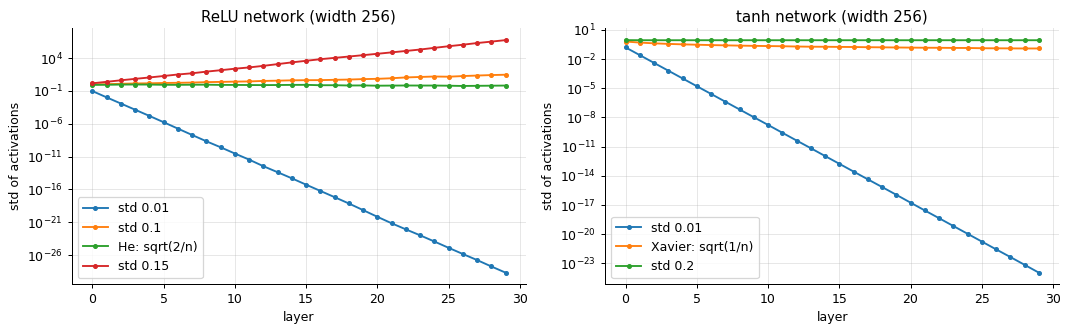

In [6]:
def activation_stds(init_std_fn, act, depth=30, width=256, m=1000):
    A = rng.normal(size=(m, width)); stds = []
    for _ in range(depth):
        W = rng.normal(0, init_std_fn(width), (width, width))
        A = act(A @ W); stds.append(A.std())
    return stds

relu = lambda z: np.maximum(0, z)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name, fn in [("std 0.01", lambda n: 0.01), ("std 0.1", lambda n: 0.1), ("He: sqrt(2/n)", lambda n: np.sqrt(2 / n)), ("std 0.15", lambda n: 0.15)]:
    axes[0].plot(activation_stds(fn, relu), "o-", ms=3, label=name)
for name, fn in [("std 0.01", lambda n: 0.01), ("Xavier: sqrt(1/n)", lambda n: np.sqrt(1 / n)), ("std 0.2", lambda n: 0.2)]:
    axes[1].plot(activation_stds(fn, np.tanh), "o-", ms=3, label=name)
for ax, t in zip(axes, ["ReLU network (width 256)", "tanh network (width 256)"]):
    ax.set_yscale("log"); ax.set_xlabel("layer"); ax.set_ylabel("std of activations"); ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()

Only the variance-preserving initialisations keep the signal at a constant scale through 30 layers. Too small, and it vanishes exponentially. Too large, and it explodes with ReLU, or saturates tanh at ±1, where the gradient is 0.

## 7. Vanishing and exploding gradients

Unroll formula (c) from the output down to layer $l$:
$$
\boldsymbol{\delta}^{[l]} = \Big(\cdots\big(\boldsymbol{\delta}^{[L]}\mathbf{W}^{[L]\top}\odot g'(\mathbf{Z}^{[L-1]})\big)\cdots\mathbf{W}^{[l+1]\top}\Big)\odot g'(\mathbf{Z}^{[l]}).
$$
The gradient reaching an early layer is a product of $L-l$ factors "weight matrix × activation derivative". Products of many numbers either shrink or blow up exponentially:

- **Sigmoid** has $\sigma'\le\frac14$. Each layer can cut the gradient by 4×, so after 10 layers it is at most $4^{-10}\approx 10^{-6}$ (unless the weights compensate). **Vanishing gradients**: early layers barely learn. This is why sigmoid/tanh deep nets were hard to train before ~2010.
- Large weights make the factors $>1$: **exploding gradients** (loss becomes NaN). Very common in RNNs (notebook 04).

**Remedies** (all used in practice): ReLU-family activations; proper initialisation (section 6); normalisation layers (BatchNorm/LayerNorm, notebook 02); **residual connections** $\mathbf{a}^{[l+1]} = \mathbf{a}^{[l]} + F(\mathbf{a}^{[l]})$, whose Jacobian $\mathbf{I} + \partial F/\partial\mathbf{a}$ always contains the identity, so the gradient has a direct path back (ResNet, transformers); **gradient clipping** for explosions.

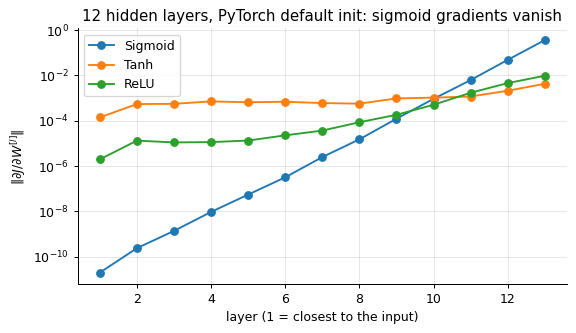

In [7]:
import torch, torch.nn as nn
torch.manual_seed(0)
Xt = torch.tensor(Xm, dtype=torch.float32); Yt = torch.tensor(Ym, dtype=torch.float32)

def grad_norms(act, depth=12, width=32):
    layers, n_in = [], 2
    for _ in range(depth):
        layers += [nn.Linear(n_in, width), act()]; n_in = width
    net = nn.Sequential(*layers, nn.Linear(width, 1))
    loss = nn.BCEWithLogitsLoss()(net(Xt), Yt); loss.backward()
    return [m.weight.grad.norm().item() for m in net if isinstance(m, nn.Linear)]

plt.figure(figsize=(6.5, 3.8))
for act in [nn.Sigmoid, nn.Tanh, nn.ReLU]:
    plt.plot(range(1, 14), grad_norms(act), "o-", label=act.__name__)
plt.yscale("log"); plt.xlabel("layer (1 = closest to the input)"); plt.ylabel(r"$\|\partial J/\partial W^{[l]}\|$")
plt.title("12 hidden layers, PyTorch default init: sigmoid gradients vanish"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Automatic differentiation in PyTorch

Writing the backward pass by hand is error-prone. PyTorch records every operation on tensors with `requires_grad=True` in a graph during the forward pass. `loss.backward()` then runs reverse-mode autodiff through that graph and stores each gradient in `param.grad`. It is exactly the algorithm of section 4, derived automatically for any architecture.

Below: the same network and data as our NumPy `MLP`, with gradients compared.

In [8]:
net_np = MLP([3, 5, 4, 1], np.random.default_rng(1))
net_np.loss(Xs, Ys); dW_np, db_np = net_np.backward(Ys)

Ws = [torch.tensor(W, requires_grad=True) for W in net_np.W]
bs = [torch.tensor(b, requires_grad=True) for b in net_np.b]
A = torch.tensor(Xs)
for l in range(3):
    Z = A @ Ws[l] + bs[l]
    A = torch.relu(Z) if l < 2 else Z                      # last layer: keep the logit
loss = nn.functional.binary_cross_entropy_with_logits(A, torch.tensor(Ys))
loss.backward()                                           # reverse-mode autodiff
for l in range(3):
    print(f"layer {l+1}: max |dW_numpy - dW_torch| = {np.abs(dW_np[l] - Ws[l].grad.numpy()).max():.2e}")

layer 1: max |dW_numpy - dW_torch| = 2.08e-17
layer 2: max |dW_numpy - dW_torch| = 2.17e-17
layer 3: max |dW_numpy - dW_torch| = 1.73e-17


Things to know about autograd:
- Gradients **accumulate** in `.grad`: that's why the training loop calls `optimizer.zero_grad()` before each `backward()` (notebook 02).
- `with torch.no_grad():` switches off graph recording (evaluation, inference, manual weight updates).
- `tensor.detach()` cuts a tensor out of the graph.

## Summary

- Backprop = chain rule applied from the loss backwards, reusing stored forward values; cost ≈ a few forward passes.
- Error signal $\boldsymbol{\delta}^{[l]} = \partial J/\partial\mathbf{Z}^{[l]}$: $\;\boldsymbol{\delta}^{[L]} = \frac1m(\mathbf{A}^{[L]}-\mathbf{Y})$, $\;\partial J/\partial\mathbf{W}^{[l]} = \mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]}$, $\;\partial J/\partial\mathbf{b}^{[l]} = \sum_i\boldsymbol{\delta}^{[l]}_{i,:}$, $\;\boldsymbol{\delta}^{[l-1]} = (\boldsymbol{\delta}^{[l]}\mathbf{W}^{[l]\top})\odot g'(\mathbf{Z}^{[l-1]})$.
- Check hand-written gradients with finite differences.
- Initialise randomly (break symmetry), with variance $1/n_{\text{in}}$ (Xavier) or $2/n_{\text{in}}$ (He, ReLU) to keep signals stable.
- Deep products of Jacobians vanish or explode; ReLU, good init, normalisation, residual connections and clipping fix this.
- PyTorch autograd does all of this automatically; remember `zero_grad()` and `no_grad()`.